# Chapter 5b | Support Vector Machines (SVMs)

(This chapter was originally included as Chapter 5 in the *Hands-On Machine Learning with Scikit-Learn, Keras and Tensorflow (III Edition)* and was then removed from the newer *Hands-On Machine Learning with Scikit-Learn and PyTorch*)

**SVM** is a powerful and versatile ML model capable of performing linear or nonlinear classification, regression and even novelty detection.

They perform well with small to medium-sized nonlinear datasets (i.e., hundreds of thousands of instances) but they don't scale well with very large datasets.

## Linear SVM Classification
We can think of SVM classifier as fitting the widest possible street between classes; this is called **Large Margin Classification**. Notice how the instances effectively determining the boundary are the ones located on the edge of the street: these are called the **Support Vectors** (the ones circled in the image below).

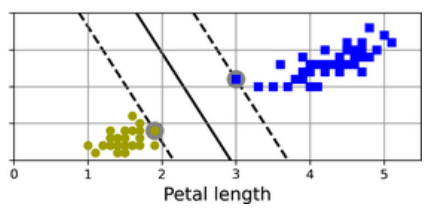

SVMs are sensitive to feature scales:

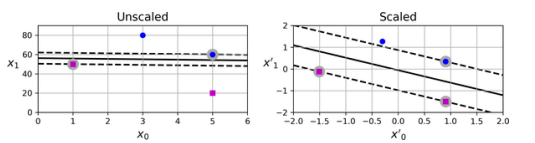

### Regularization

In SVMs, Regularization regards the "softness" of the margin (in scikit, it is the *C* hyperparameter):
- **Small C** -> **High Regularization** -> **Soft Margin Classification**: more instances support the street, larger street, more margin violations, less misclassification penalization, high bias, low variance (less overfitting, may underfit)
- **Large C** -> **Low Regularization** -> **Hard Margin Classification**: less instances support the street, narrower street, less margin violations, more misclassification penalization, low bias, high variance (more proned to overfitting)

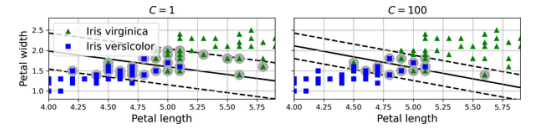

### Example
Let's train a Linear SVM classifier on the Iris dataset (we will just use 2 predictors and a binary target):

In [1]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame = True)
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = (iris.target == 2) # iris virginica

svm_clf = make_pipeline(StandardScaler(),
                        LinearSVC(C = 1, random_state=42))
svm_clf.fit(X, y)

,steps,"[('standardscaler', ...), ('linearsvc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


Let's use it to make predictions on some new fake flowers:

In [2]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

(First is Iris Virginica, second is not)

We can also look at the scores used to make these predictions, which are the distance (with sign + or -) between the instance and the decision boundary:

In [3]:
svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761])

Unlinke *LogisticRegression*, *LinearSVC* doesn't have a *predict_proba()* method; a possibility is to use *SVC* instead, setting the hyperparameter *probability=True*: this will re-train a new model with 5-fold CV to generate predictions and then train a *LogisticRegression* model to get the estimated probability, slowing down the training considerably (after that, you can use *predict_proba()* and *predict_log_proba()*).

## NonLinear SVM Classification

### Adding Polynomial Features

*Linear SVM* works very well with **linearly separable** datasets; when handling with nonlinear datasets, a possibility is to **add more features** (e.g., polynomial features) to try to end in a linearly separable dataset. Below an example of a not linearly separable dataset with one feature $x_1$ (left) and a linearly separable dataset obtained by adding a second feature $x_1^2$ (right):

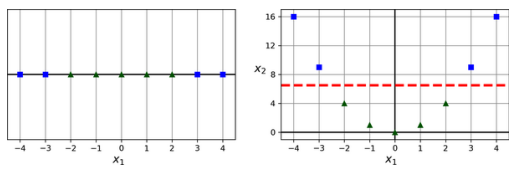

Let's see an example of this with the moons dataset (a toy dataset in which data points are shaped as a 2 interleaving crescent moons):

In [4]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples = 100, noise = 0.15, random_state = 42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree = 3),
    StandardScaler(),
    LinearSVC(C = 10, max_iter = 10_000, random_state = 42)
)

polynomial_svm_clf.fit(X, y)

,steps,"[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


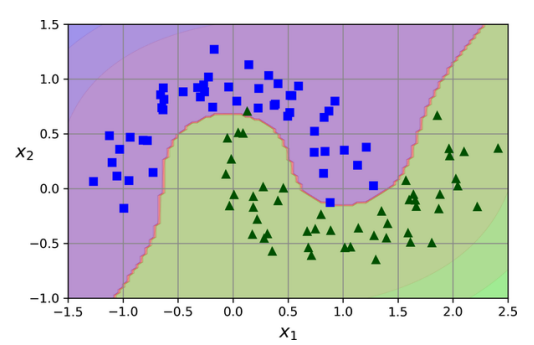

### Polynomial Kernel
Adding Polynomial Features works well with a lot of ML algorithms; but, when dealing with too complex datasets, low degree polynomial doesn't work well, while high degree polynomial would add to much features, making the model slow.

When working with SVMs, we can apply the so called **Kernel Trick**, which enables to get the same result of adding many polynomial features, without effectively adding them. This trick is implemented by the *SVC* class:

In [5]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel = 'poly', degree = 3, coef0 = 1, C = 5))

poly_kernel_svm_clf.fit(X, y)

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,5
,kernel,'poly'
,degree,3
,gamma,'scale'


Below a comparisong of lower degree (left) and higher degree (right); also, the *coef0* hyperparameter is changing: this controls how much the model is influenced by high-degree terms versus low-degree terms:

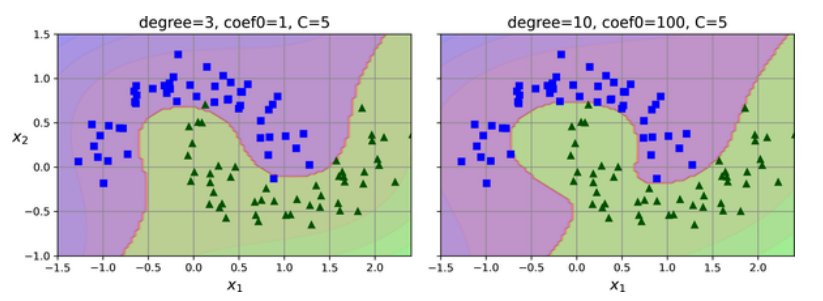

### Similarity Features
Another way of tackling nonlinear problems is to add **Similarity Features** computed using a **Similarity Function** measuring how much an instance resembles a particular **landmark**.

Let's make an example with the previous 1D Dataset adding 2 landmarks at $x_1 = -2$ and $x_1 = 1$. We then use the **Gaussian RBF** with $\gamma = 0.3$ as similarity function: this is a bell-shaped function varying from 0 (instance very far away from landmark) to 1 (the landmark). 

Taking the instance $x_1 = -1$, it would have:
- $x_2 = exp(-0.3 \cdot 1^2) \approx 0.74$
- $x_3 = exp(-0.3 \cdot 2^2) \approx 0.30$.

Below the original dataset (left) and new dataset obtained by also dropping the original feature (right)

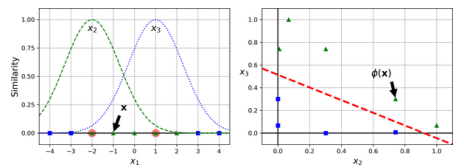

The dataset is now linearly separable!

But, how do we choose a landmark? An idea is to put a landmark on each training instance (havin $m$ instances and $n$ features in the original dataset, this would take to a $m$ x $m$ one).

### Gaussian RBF Kernel
Just as polynomial features method was useful but computationally expensive, the similarity features method work the same, and just as the former, the kernel trick allows to obtain a similar result without doing it:

In [6]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                   SVC(kernel = 'rbf', gamma = 5, C = 0.001))
rbf_kernel_svm_clf.fit(X, y)

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,0.001
,kernel,'rbf'
,degree,3
,gamma,5


Below a comparison of different models obtained with different hyperparameters:

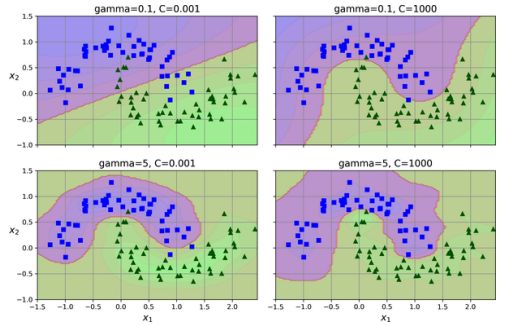

It's easy to see the influence of both hyperparameters:
- $\gamma$: 
  - the higher it is, the more the bell-shaped curve is narrower (each instance's range of influence is smaller), taking to fit each training point almost perfectly (so more proned to overfit); 
  - the lower it is, the more the bell-shaped curve is wider (each instance's range of influence is higher), taking to capture general trends and not small detailed ones (so more proned to underfit);
- $C$: (as before):
  - the higher it is, the more misclassifications are penalized (so more proned to overfit);
  - the lower it is, the less misclassifications are penalized (so more proned to unferfit).

We can use both for regularize our model (we can decrease both in case of overfitting).

### Which Kernel to use?
As a rule of thumb, at first try *LinearSVC* (it is much faster than *SVC(kernel = 'linear')*); if dataset is not too large, try other kernels, starting from Gaussian RBF. Experiment with others if you have time and computing power, or if any kernel is specialized for your training set's structure.

### SVM and Computational Complexity
- *LinearSVC* -> $O(m \times n)$: it's an optimized algorithm implementation (tolerance hyperparameter $\epsilon$ can decrease time if lower);
- *SVC* -> from $O(m^2 \times n)$ to $O(m^3 \times n)$: it's an algorithm supporting the kernel trick which scales well with number of features, but not with number of instances;
- *SGDClassifier* -> $O(m \times n)$: it's a SGD implementation which scales very well.

## SVM Regression
Instead of trying to fit the largest possible street between 2 classes limiting the margin violations (classification), now it tries to fit as many instances as possible **on the street** while limiting margin violations (**off the street**). 

We can control the width of the street with the hyperparameter $\epsilon$ (*epsilon* in scikit):

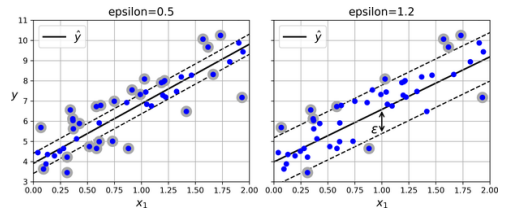

Lowering $\epsilon$ increases the number of support vectors, regularizing the model; adding more training instance within the margin will not affect the predictions, making the model $\epsilon$**-insensitive**.

As for Classification, we got different classes implementing different algorithms:
- *LinearSVR* (equivalent of *LinearSVC*): scales linearly with size of training;
- *SVR* (equivalent of *SVC*): doesn't scale well with number of instances.

## Under the Hood of Linear SVM Classifiers
To make predictions, it computes the **Decision Function**:

$$\theta^T x = \theta_0 x_0 + ...+ \theta_n x_n$$

where $x_0$ is the **bias term**, always equal to 1.

If this result is positive, then predicted class $\hat y$ is the positive class (1), otherwise is the negative class (0) (this is how *LogisticRegression* worked).

What about the training?

If we call:
- $w$: the **feature weights vector** (from $\theta_1$ to $\theta_n$, so excluding the bias feature $\theta_0$);
- $b$: the **bias term** ($\theta_0$).

Training an SVM classifier means finding $w$ and $b$ making the margin as wide as possible while limiting the margin violations. Looking to a 2D example, we can see how we get wider margin, the smaller $w$ is: consider the borders of the margin to be the points where the decision function is -1 or +1; now:
  - if weight $w_1$ is 1 (left plot), the decision function $w_1x_1$ will be -1 or +1 when $x_1$ is -1 and $x_1$ is +1, so the margin is 2;
  - if weight $w_1$ is 0.5 (right plot), the decision function $w_1x_1$ will be -1 or +1 when $x_1$ is -2 and $x_1$ is +2, so the margin is 4.

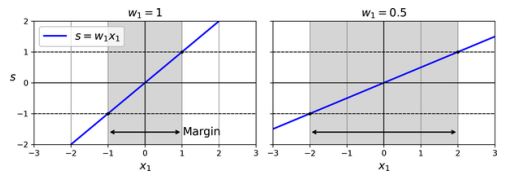

So, $w$ should be the smaller as possible. Note how $b$ doesn't affect the size of margin, but it just shifts it around.

We also want to avoid margin violations, so decision function must be greater than 1 for all positive instances and lower than -1 for negative. If we define $t^{(i)} = -1$ for negative instances (when $y^{(i)} = 0$) and $t^{(i)} = +1$ for positive instances (when $y^{(i)} = 1$), then we can write the constraint as $t^{(i)}(w^Tx^{(i)} + b) \ge 1$ for all instances.

This takes the **hard margin linear SVM classifier objective** to be the constrained optimization problem:

$$minimize_{w, b} \space \frac 1 2 w^T w$$
$$subject \space to \space t^{(i)}(w^Tx^{(i)} + b) \ge 1 \space for \space i = 1, 2, ..., m $$

(Instead of minimizing the norm of $w$, we minimize $\frac 1 2 w^T w$ because it has a simple derivative)

To get the **soft margin linear SVM classifier objective**, we introduce a **slack variable** $\zeta^{(i)} \ge 0$ (zeta greek letter): this measures how much the $i^{th}$ instance is allowed to violate the margin; since we now have 2 constraints which are minimizing the slack variable to reduce margin violations and minimize $\frac 1 2 w^T w$ to increase the margin, we use the hyperparameter $C$ to define a trade-off between these 2:

$$minimize_{w, b, \zeta} \space \frac 1 2 w^T w + C \sum_{i = 1}^m \zeta^{(i)}$$
$$subject \space to \space t^{(i)}(w^Tx^{(i)} + b) \ge 1 - \zeta^{(i)}  \space for \space i = 1, 2, ..., m $$

Both Hard and Soft margin problems are **Convex Quadratic Optimization Problems** with **Linear Constraints**, which are known as **Quadratic Programming (QP)** problems and can be solved with variety of techniques, such as using a QP solver.

Another way is to use gradient descent to minimize the **Hinge Loss** or the **Squared Hinge Loss**, for which loss is 0 if the output of the decision function $s$ is $\ge$ 1, when $x$ is a positive instance, or when $s \le -1$, when $x$ is a negative instance. The more the instance is further away from the correct side of the margin, the higher loss is (linearly if Hinge Loss, quadratically if Squared Hinge Loss; so Squared Hinge Loss is more sensitive to outliers, while it converges faster when dataset is clean). 

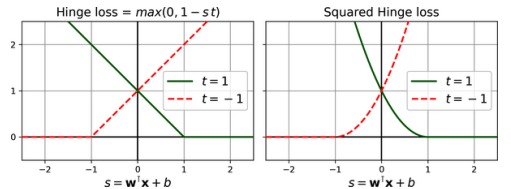

By default, *LinearSVC* uses Squared Hinge Loss, *SGDClassifier* uses Hinge Loss (we can put *loss=* to both *'hinge'* or *'squared_hinge'* to change); *SVC* finds a similar solution as minimizing the Hinge Loss.

#### Dual Problem

Another way to train a SVM classifier is by solving the **Dual Problem**: given a constrained optimization problem, the **Primal Problem**, it is possible to express a different but closely related problem, the **Dual Problem**; it typically gives a lower bound to the solution of the primal, but under some conditions it gives the same solution (SVM meets these conditions).

Below the Dual Form of Linear SVM objective:

$$ minimize_\alpha \space \frac 1 2 \sum_{i = 1}^{m}\sum_{j = 1}^m \alpha^{(i)} \alpha^{(j)} t^{(i)} t^{(j)} x^{(i)T} x^{(j)} - \sum_{i =1}^m \alpha^{(i)}$$

$$ subject \space to \space \alpha^{(i)} \ge 0 \space for \space all \space i = 1, 2, ..., m \space and \space \sum_{i = 1}^m \alpha^{(i)} t^{(i)} = 0 $$

Once we found the vector $\hat \alpha$ minimizing this (using a QP solver), we use it to compute $\hat w$ and $\hat b$ that minimize the primal problem:

$$ \hat w = \sum_{i = 1}^m \alpha^{(i)}t^{(i)}x^{(i)}$$

$$\hat b = \frac 1 {n_s} \sum_{i = 1, \hat \alpha^{(i)} > 0} (t^{(i)} - \hat w^T x^{(i)})$$

where $n_s$ is the number of support vectors.

The dual problem is faster to solve than the primal when number of training instances is smaller than number of features. This dual problem allows for the kernel trick.

But, what is the **Kernel Trick**?

#### Kernelized SVMs

Suppose we want to apply a 2-degree polynomial transformation to a 2-dimensional training set and then train a linear SVM classifier on it; the **2-degree polynomial mapping function** we would like to apply would be:

$$ \phi(x) = \phi(
    \begin{pmatrix}
    x_1 \\
    x_2
    \end{pmatrix}
) = \begin{pmatrix}
x_i^2 \\
\sqrt 2 x_1 x_2 \\
x_2^2
\end{pmatrix}$$

If we apply this to a couple of 2D vectors $a$ and $b$ and then compute the dot product of the transformed vectors we obtain:

$$ \phi(a)^T \phi(b) = \begin{pmatrix} a_1^2 \\ \sqrt 2 a_1 a_2 \\ a_2^2 \end{pmatrix} \begin{pmatrix} b_1^2 \\ \sqrt 2 b_1 b_2 \\ b_2^2 \end{pmatrix} = a_1^2b_1^2 + 2a_1b_1a_2b_2 + a_2^2b_2^2 = (a_1b_1 + a_2b_2)^2 = (\begin{pmatrix} a_1 \\ a_2 \end{pmatrix}^T \begin{pmatrix} b_1 \\ b_2 \end{pmatrix})^2 = (a^Tb)^2$$

The important thing is:

$$ \phi(a)^T \phi(b) = (a^Tb)^2$$

So, the dot product of the transformed vectors is the square of the dot product ot the original vectors. 

More generally, in ML a **Kernel** is a function capable of computing the dot product $$ \phi(a)^T \phi(b)$$ based only on the original vectors $a$ and $b$ without the need to compute the transformation. Some of the most commonly used kernels are:
- **Linear**: $K(a, b) = a^T b$
- **Polynomial**: $K(a, b) = (\gamma a^T b + r)^d$
- **Gaussian RBF**: $K(a, b) = exp(-\gamma ||a -b ||^2)$
- **Sigmoid**: $K(a, b) = tanh(\gamma a^T b + r)$

(Watch **Mercer's Theorem** for more info about Kernels)

Once we applied the Kernel trick, we then plug the formula for $\hat w$ into the decision function for a new instance $x^{(n)}$ obtaining an equation with only dot product between input vectors, which is the formula to make predictions with a Kernelized SVM:

$$ h_{\hat w, \hat b}(\phi(x^{(n)})) = $$
$$ = \hat w^T \phi(x^{(n)}) +\hat b = $$
$$ = (\sum_{i = 1}^m \hat \alpha^{(i)} t^{(i)} \phi(x^{(i)}))^T \phi(x^{(n)}) + \hat b = $$
$$ = \sum_{i = 1}^m \hat \alpha^{(i)} t^{(i)} (\phi(x^{(i)})^T \phi(x^{(n)})) + \hat b = $$
$$ = \sum_{i = 1, \hat \alpha^{(i)} > 0}^m \hat \alpha^{(i)} t^{(i)} K (x^{(i)}, x^{(n)}) + \hat b$$

We can then use the Kernel trick to get $\hat b$:

$$ \hat b = \frac 1 {n_s} \sum_{i = 1, \hat \alpha^{(i)} > 0}^m (t^{(i)} - \hat w^T \phi (x^{(i)})) =$$
$$ = \frac 1 {n_s} \sum_{i = 1, \hat \alpha^{(i)} > 0}^m (t^{(i)} - (\sum_{j = 1, \hat \alpha^{(j)} > 0}^m \hat \alpha^{(j)} t^{(j)} \phi(x^{(j)}))^T \phi(x^{(i)})) =$$
$$ = \frac 1 {n_s} \sum_{i = 1, \hat \alpha^{(i)} > 0}^m (t^{(i)} - \sum_{j = 1, \hat \alpha^{(j)} > 0}^m \hat \alpha^{(j)} t^{(j)} K(x^{(i)}, x^{(j)})) $$